In [1]:
# cpu cores for sampling
# os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=4'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd


import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import hpdi


from numpyro.infer import MCMC, NUTS, Predictive

import arviz as az

# Data pre processing

In [2]:
# stage height data

#Downstream
glenreagh_stageheight_all = pd.read_csv('./../data/orara/stageheight_glenreagh.csv',skiprows=9)
glenreagh_stageheight_all['Date'] = pd.to_datetime(glenreagh_stageheight_all['#Timestamp'])

#Upstream
orange_stageheight_all = pd.read_csv('./../data/orara/stageheight_orange.csv',skiprows=9)
orange_stageheight_all['Date'] = pd.to_datetime(orange_stageheight_all['#Timestamp'])

In [26]:
# rain data

nanaglen_rain = pd.read_csv('./../data/orara/nana_glen.csv')
nanaglen_rain['dateInt']=nanaglen_rain['Year'].astype(str) + nanaglen_rain['Month'].astype(str).str.zfill(2)+ nanaglen_rain['Day'].astype(str).str.zfill(2)

nanaglen_rain['Date'] = pd.to_datetime(nanaglen_rain['dateInt'],format='%Y%m%d')

# time period decission

y_l = 2008
y_h = 2010

#slicing

dates_train = glenreagh_stageheight_all['Date'][(glenreagh_stageheight_all['Date'].dt.year>=y_l)&(glenreagh_stageheight_all['Date'].dt.year<=y_h)].dt.date
dates_test = glenreagh_stageheight_all['Date'][(glenreagh_stageheight_all['Date'].dt.year>=y_h+1)&(glenreagh_stageheight_all['Date'].dt.year<=y_h+1)].dt.date

hu_train = orange_stageheight_all['Value'][(orange_stageheight_all['Date'].dt.year>=y_l)&(orange_stageheight_all['Date'].dt.year<=y_h)].values
r_train = nanaglen_rain['Value'][(nanaglen_rain['Date'].dt.year>=y_l)&(nanaglen_rain['Date'].dt.year<=y_h)].values
hd_train = glenreagh_stageheight_all['Value'][(glenreagh_stageheight_all['Date'].dt.year>=y_l)&(glenreagh_stageheight_all['Date'].dt.year<=y_h)].values

hu_test = orange_stageheight_all['Value'][(orange_stageheight_all['Date'].dt.year>=y_h+1)&(orange_stageheight_all['Date'].dt.year<=y_h+1)].values
r_test = nanaglen_rain['Value'][(nanaglen_rain['Date'].dt.year>=y_h+1)&(nanaglen_rain['Date'].dt.year<=y_h+1)].values
hd_test = glenreagh_stageheight_all['Value'][(glenreagh_stageheight_all['Date'].dt.year>=y_h+1)&(glenreagh_stageheight_all['Date'].dt.year<=y_h+1)].values

ticklabels_train = dates_train.astype(str).values
ticklabels_test = dates_test.astype(str).values


# Helper functions

In [5]:
def nan_dates(df,c):
    return np.where(np.isnan(df),c,np.nan),np.where(~np.isnan(df),c,np.nan)

def zero_dates(df,c):
    return np.where(df==0,c,np.nan),np.where(df!=0,c,np.nan)

def nan_plot(df,ticks,c,i):
    nans,no_nans = nan_dates(df,c)
    plt.figure(figsize=(15,5))
    tot = len(nans) + len(no_nans)
    plt.scatter([x for x in range(len(no_nans))],no_nans,c='green')
    plt.scatter([x for x in range(len(nans))],nans,c='red',s=50)
    plt.xticks(ticks=[x for x in range(0,len(nans),i)],labels=[ticks[x] for x in range(0,len(nans),i)],rotation=90)
    plt.show()

def zero_plots(df,ticks,c,i):
    nans,no_nans = zero_dates(df,c)
    plt.figure(figsize=(15,5))
    tot = len(nans) + len(no_nans)
    plt.scatter([x for x in range(len(no_nans))],no_nans,c='green')
    plt.scatter([x for x in range(len(nans))],nans,c='red',s=50)
    plt.xticks(ticks=[x for x in range(0,len(nans),i)],labels=[ticks[x] for x in range(0,len(nans),i)],rotation=90)
    plt.show()

def min_max_norm(x):
    return (x-x.min())/(x.max()-x.min())

def min_max_norm_t(x, min_val, max_val):
    return (x-min_val)/(max_val-min_val)

****************************** Downstream height data ******************************


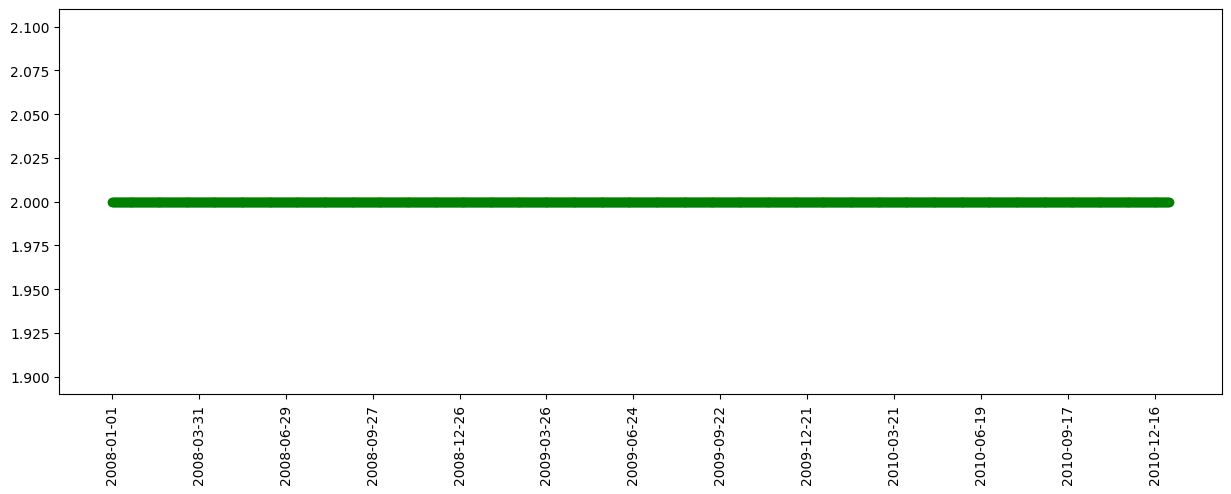

****************************** Upstream height data ******************************


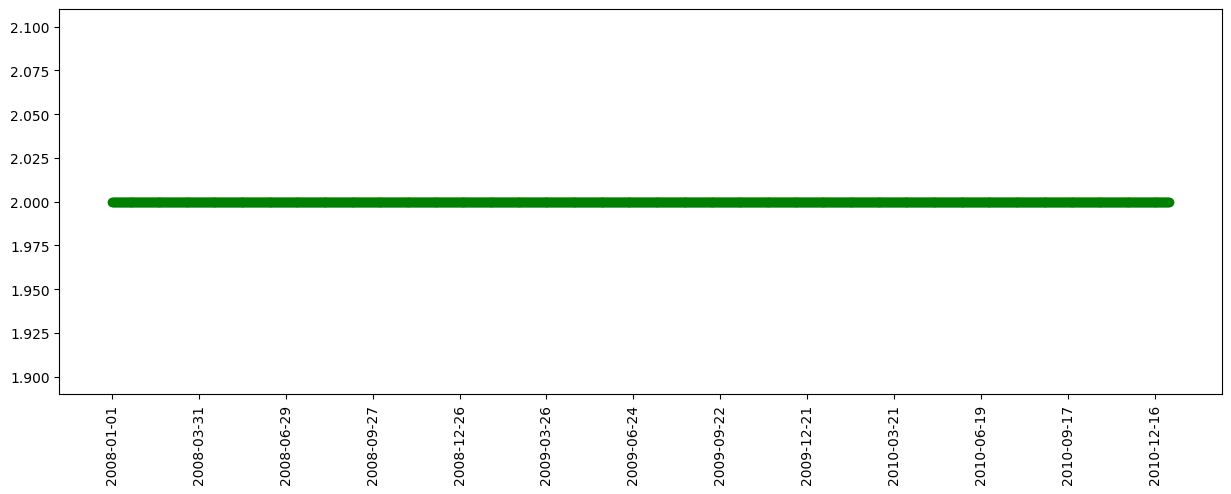

****************************** Rain data ******************************


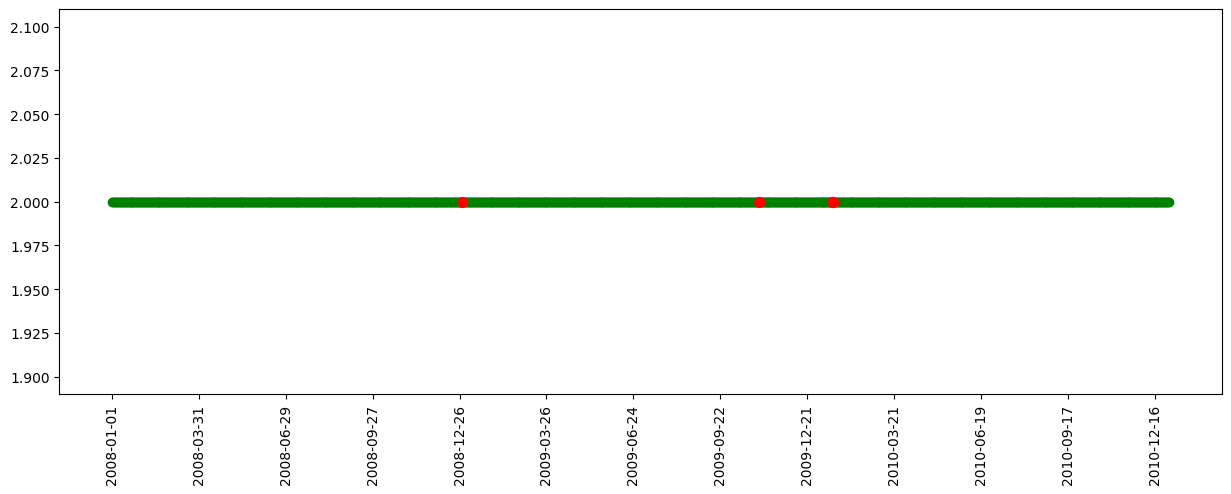

In [9]:
# Plotting the availability of data for training period

print('*'*30,'Downstream height data','*'*30)
nan_plot(hd_train,ticklabels_train,2,90)
print('*'*30,'Upstream height data','*'*30)
nan_plot(hu_train,ticklabels_train,2,90)
print('*'*30,'Rain data','*'*30)
nan_plot(r_train,ticklabels_train,2,90)

****************************** Downstream height data ******************************


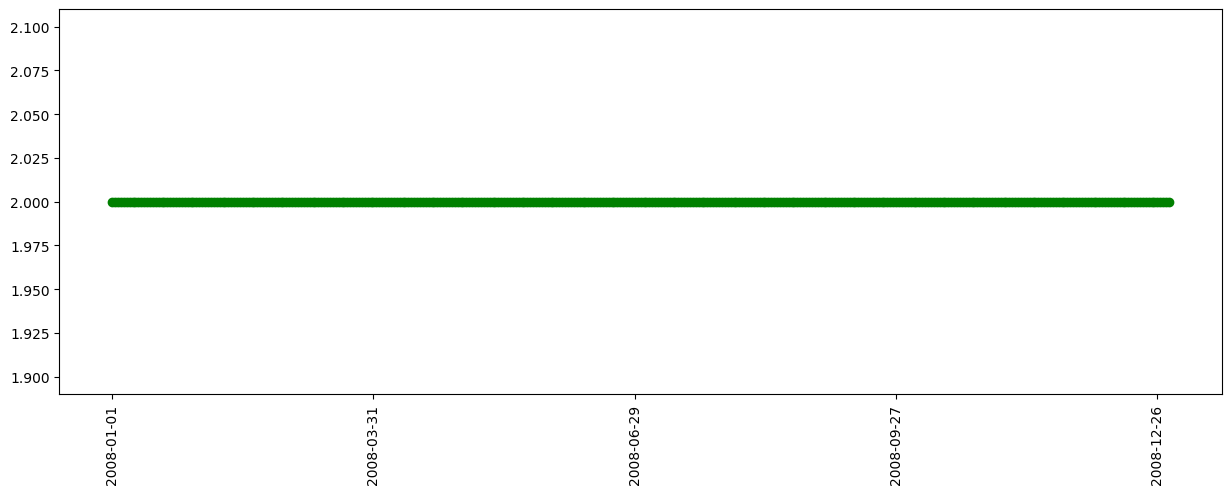

****************************** Upstream height data ******************************


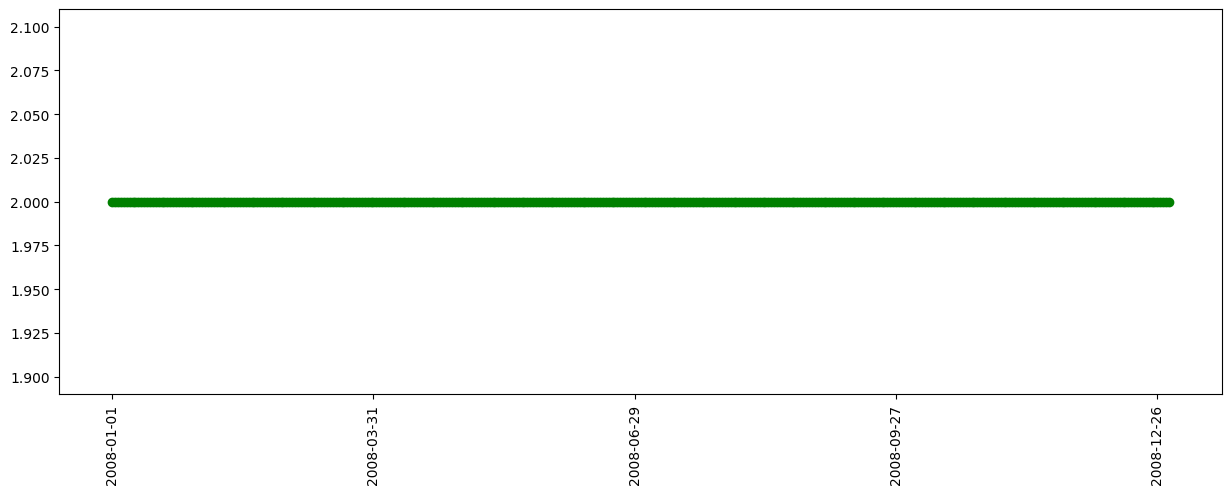

****************************** Rain data ******************************


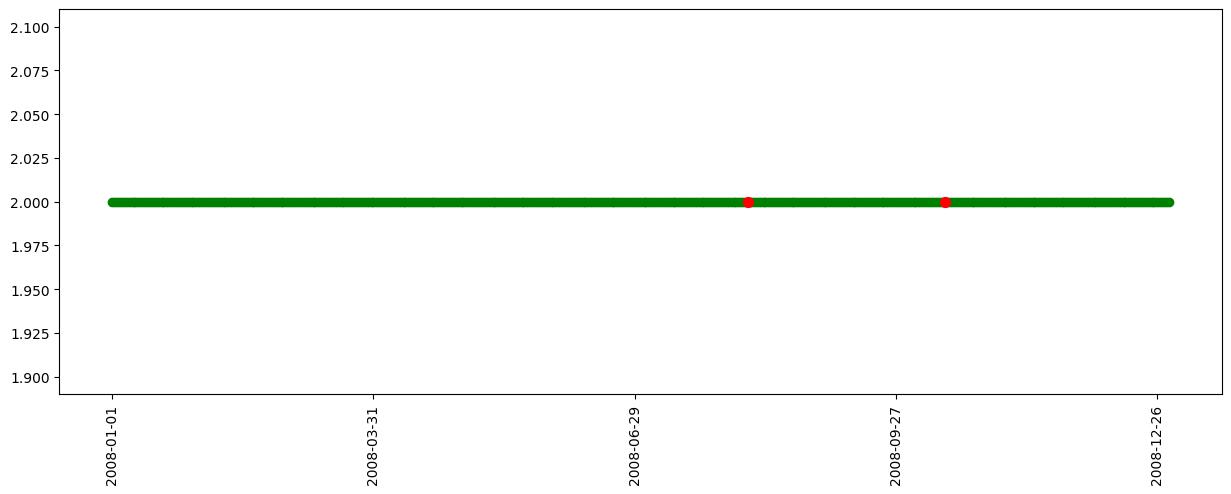

In [11]:
# Plotting the availability of data for test period

print('*'*30,'Downstream height data','*'*30)
nan_plot(hd_test,ticklabels_train,2,90)

print('*'*30,'Upstream height data','*'*30)
nan_plot(hu_test,ticklabels_train,2,90)

print('*'*30,'Rain data','*'*30)
nan_plot(r_test,ticklabels_train,2,90)

In [27]:
# training data

hu = hu_train[:-1]
r = r_train[:-1]

hd = hd_train[1:]

# remove no data days
hu = jnp.delete(hu,np.argwhere(np.isnan(r))[:,0])
hd = jnp.delete(hd,np.argwhere(np.isnan(r))[:,0])
r = jnp.delete(r,np.argwhere(np.isnan(r))[:,0])


x_train_m0 = jnp.vstack((jnp.array([1 for x in range(len(hu))]),min_max_norm(hu), min_max_norm(r)))
x_train = jnp.vstack((jnp.array([1 for x in range(len(hu))]),min_max_norm(jnp.log(hu)), min_max_norm(r), min_max_norm(jnp.log(hu)*r)))

In [28]:
# test data

hu_test = hu_test[:-1]
r_test = r_test[:-1]

hd_test = hd_test[1:]


hu_test = jnp.delete(hu_test,np.argwhere(np.isnan(r_test))[:,0])
hd_test = jnp.delete(hd_test,np.argwhere(np.isnan(r_test))[:,0])
r_test = jnp.delete(r_test,np.argwhere(np.isnan(r_test))[:,0])


x_test_m0 = jnp.vstack((jnp.array([1 for x in range(len(hu_test))]),min_max_norm_t(hu_test,np.min(hu), np.max(hu)),min_max_norm_t(r_test, np.min(r), np.max(r))))
x_test = jnp.vstack((jnp.array([1 for x in range(len(hu_test))]),min_max_norm_t(jnp.log(hu_test),np.min(jnp.log(hu)), np.max(jnp.log(hu))),min_max_norm_t(r_test, np.min(r), np.max(r)), min_max_norm_t(jnp.log(hu_test)*r_test, np.min(jnp.log(hu)*r), np.max(jnp.log(hu)*r))))

# Base model (M0)

In [29]:
# Ossandon et al. 2021 model

def single_model_m0(x,hd=None):
    n = x.shape[1]
    p = x.shape[0]
    beta = numpyro.sample('beta',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi = numpyro.sample('phi',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    mean = numpyro.deterministic('mean',x.T @ beta)
    sd = numpyro.deterministic('sd', x.T @ phi )
    
    con1 = jnp.all(beta>0)
    
    numpyro.factor("reject_beta", jnp.where(con1, 0., -jnp.inf))
    
    numpyro.sample("obs", dist.Gamma(mean**2/sd**2 ,rate=mean/sd**2), obs=hd)

In [31]:
# run several times with different rng keys!
rng_key_ = random.PRNGKey(2121)
n_samples = 10000
n_warmup = 2000

# build kernel and run NUTS
kernel = NUTS(single_model_m0, max_tree_depth=7)
mcmc_m0 = MCMC(
    kernel,
    num_warmup=n_warmup,
    num_samples=n_samples,
    num_chains=1,
)
mcmc_m0.run(rng_key_,x_train_m0,hd=hd)
trace_m0 = mcmc_m0.get_samples()

  0%|          | 0/12000 [00:00<?, ?it/s]

sample: 100%|██████████| 12000/12000 [01:18<00:00, 152.42it/s, 127 steps of size 3.21e-02. acc. prob=0.95]


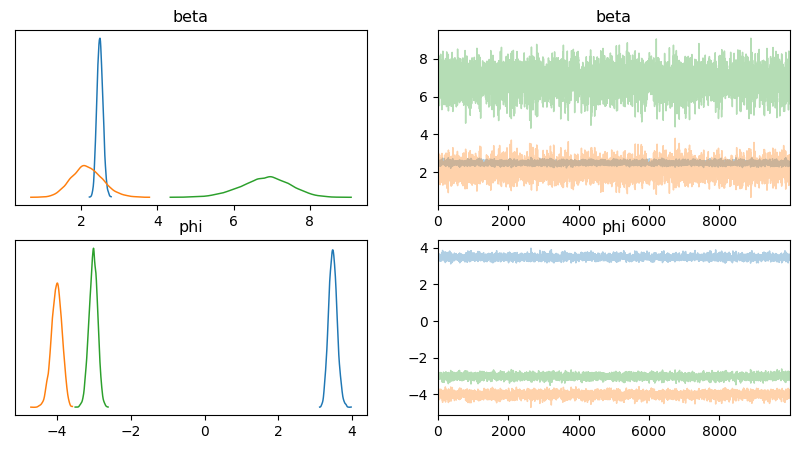

In [32]:
trace_az = {k: jnp.expand_dims(v,axis=0) for k, v in trace_m0.items()}
numpyro_data = az.from_dict(
    trace_az
)

az.plot_trace(
    numpyro_data.posterior, 
    var_names=['beta','phi'],
    figsize=(10,5)
)
None

In [33]:
posterior_predictive_m0 = Predictive(
    single_model_m0, posterior_samples=trace_m0, 
    return_sites=[
        'obs','mean'
    ])(rng_key_, x_test_m0)

# collect predictive variables
ci = 0.95

hpdi_sim_single_m0 = hpdi(posterior_predictive_m0['obs'], ci)
mean_pred_single_m0 = jnp.mean(posterior_predictive_m0['obs'],axis=0)

# Single component model (M1)

In [35]:
def single_model_m1(x,hd=None):
    n = x.shape[1]
    p = x.shape[0]
    beta = numpyro.sample('beta',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi = numpyro.sample('phi',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    
    sig_mu = numpyro.sample('sigma_mu',dist.InverseGamma(1,2))
    sig_sig = numpyro.sample('sigma_sig',dist.InverseGamma(1,2))
    
    e_mu = dist.Normal(0,sig_mu).sample(rng_key_,sample_shape=(1,n))
    e_sig = dist.Normal(0,sig_sig).sample(rng_key_,sample_shape=(1,n))

    mean = numpyro.deterministic('mean',jnp.exp(x.T @ beta + e_mu))
    sd = numpyro.deterministic('sd', jnp.exp(x.T @ phi + e_sig ))
    
    numpyro.sample("obs", dist.Gamma(mean**2/sd**2 ,rate=mean/sd**2), obs=hd)

In [36]:
# run several times with different rng keys!
rng_key_ = random.PRNGKey(321)
n_samples = 10000
n_warmup = 2000
# build kernel and run NUTS
kernel = NUTS(single_model_m1, max_tree_depth=5)#, jit_compile=True, ignore_jit_warnings=True)
mcmc_m1 = MCMC(
    kernel,
    num_warmup=n_warmup,
    num_samples=n_samples,
    num_chains=1,
)
mcmc_m1.run(rng_key_,x_train,hd=hd)
trace_m1 = mcmc_m1.get_samples()

sample: 100%|██████████| 12000/12000 [00:39<00:00, 303.00it/s, 31 steps of size 9.79e-02. acc. prob=0.78]


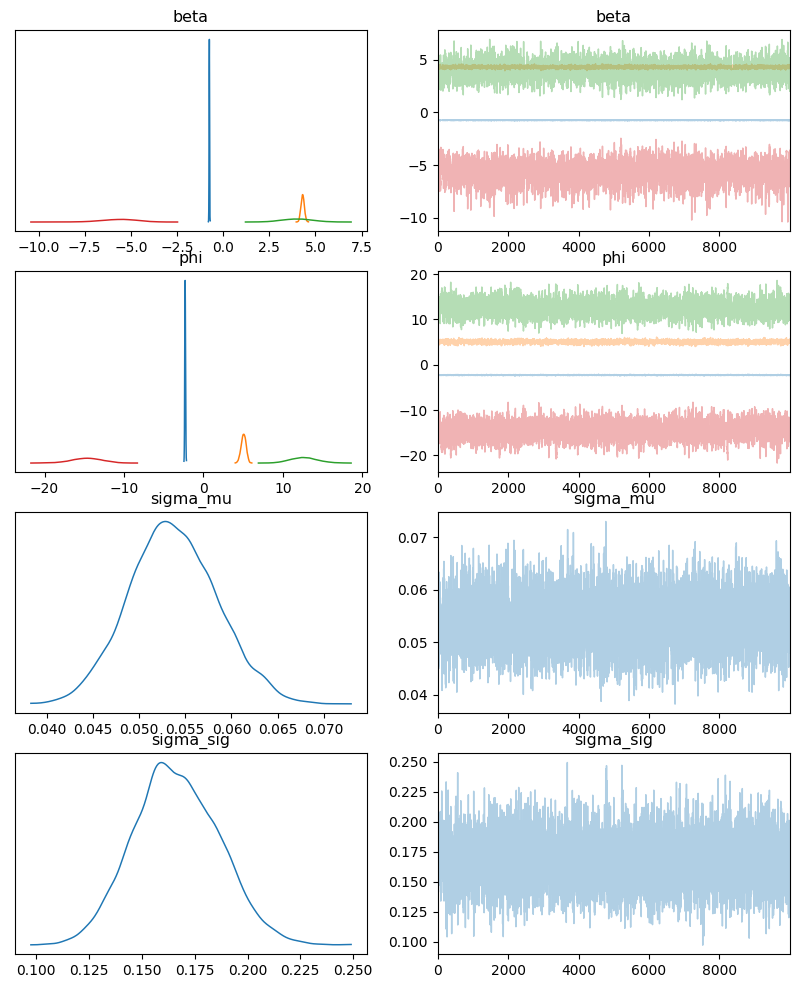

In [38]:
trace_az = {k: jnp.expand_dims(v,axis=0) for k, v in trace_m1.items()}
numpyro_data = az.from_dict(
    trace_az
)

az.plot_trace(
    numpyro_data.posterior, 
    var_names=['beta','phi', 'sigma_mu', 'sigma_sig'],
    figsize=(10,12)
)
None

In [39]:
posterior_predictive_m1 = Predictive(
    single_model_m1, posterior_samples=trace_m1, 
    return_sites=[
        'obs','mean'
    ])(rng_key_, x_test)

# collect predictive variables
ci = 0.95

hpdi_sim_single_m1 = hpdi(posterior_predictive_m1['obs'], ci)
mean_pred_single_m1 = jnp.mean(posterior_predictive_m1['obs'],axis=0)

# BHME model (M2)

In [41]:
def mixture_model_m2(x,hd=None):
    n = x.shape[1]
    p = x.shape[0]
    
    beta1 = numpyro.sample('beta1',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi1 = numpyro.sample('phi1',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    beta2 = numpyro.sample('beta2',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi2 = numpyro.sample('phi2',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    omega = numpyro.sample('omega',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    sig_mu1 = numpyro.sample('sig_mu1', dist.InverseGamma(1,2))
    sig_mu2 = numpyro.sample('sig_mu2', dist.InverseGamma(1,2))

    sig_sig1 = numpyro.sample('sig_sig1', dist.InverseGamma(1,2))
    sig_sig2 = numpyro.sample('sig_sig2', dist.InverseGamma(1,2))

    e_mu1 = dist.Normal(0,sig_mu1).sample(rng_key_,sample_shape=(1,x.shape[1]))
    e_mu2 = dist.Normal(0,sig_mu2).sample(rng_key_,sample_shape=(1,x.shape[1]))

    e_sig1 = dist.Normal(0,sig_sig1).sample(rng_key_,sample_shape=(1,x.shape[1]))
    e_sig2 = dist.Normal(0,sig_sig2).sample(rng_key_,sample_shape=(1,x.shape[1]))


    mean1 = numpyro.deterministic('mean1',jnp.exp(x.T @ beta1 + e_mu1))
    sd1 = numpyro.deterministic('sd1', jnp.exp(x.T @ phi1 + e_sig1))

    mean2 = numpyro.deterministic('mean2',jnp.exp(x.T @ beta2 + e_mu2))
    sd2 = numpyro.deterministic('sd2', jnp.exp(x.T @ phi2 + e_sig2))

    comp1 = dist.Gamma(mean1**2/sd1**2, rate=mean1/sd1**2)
    comp2 = dist.Gamma(mean2**2/sd2**2, rate=mean2/sd2**2)

    w_exp = jnp.exp(x.T @ omega)
    w_1 = w_exp / (1 + w_exp)
    gate = numpyro.deterministic('gate',jnp.stack((w_1, 1- w_1), axis = -1))
    mixture = dist.MixtureGeneral(dist.Categorical(probs=gate), [comp1,comp2])

    numpyro.sample('obs', mixture, obs=hd)

In [42]:
# run several times with different rng keys!
#rng_key_ = random.PRNGKey(112)
rng_key_ = random.PRNGKey(32112)
n_samples = 10000
n_warmup = 2000
# build kernel and run NUTS
kernel = NUTS(mixture_model_m2, max_tree_depth=5)
mcmc_m3 = MCMC(
    kernel,
    num_warmup=n_warmup,
    num_samples=n_samples,
    num_chains=1,
)
mcmc_m3.run(rng_key_,x_train,hd=hd)
trace_m3 = mcmc_m3.get_samples()

sample: 100%|██████████| 12000/12000 [02:01<00:00, 98.56it/s, 31 steps of size 3.36e-02. acc. prob=0.91] 


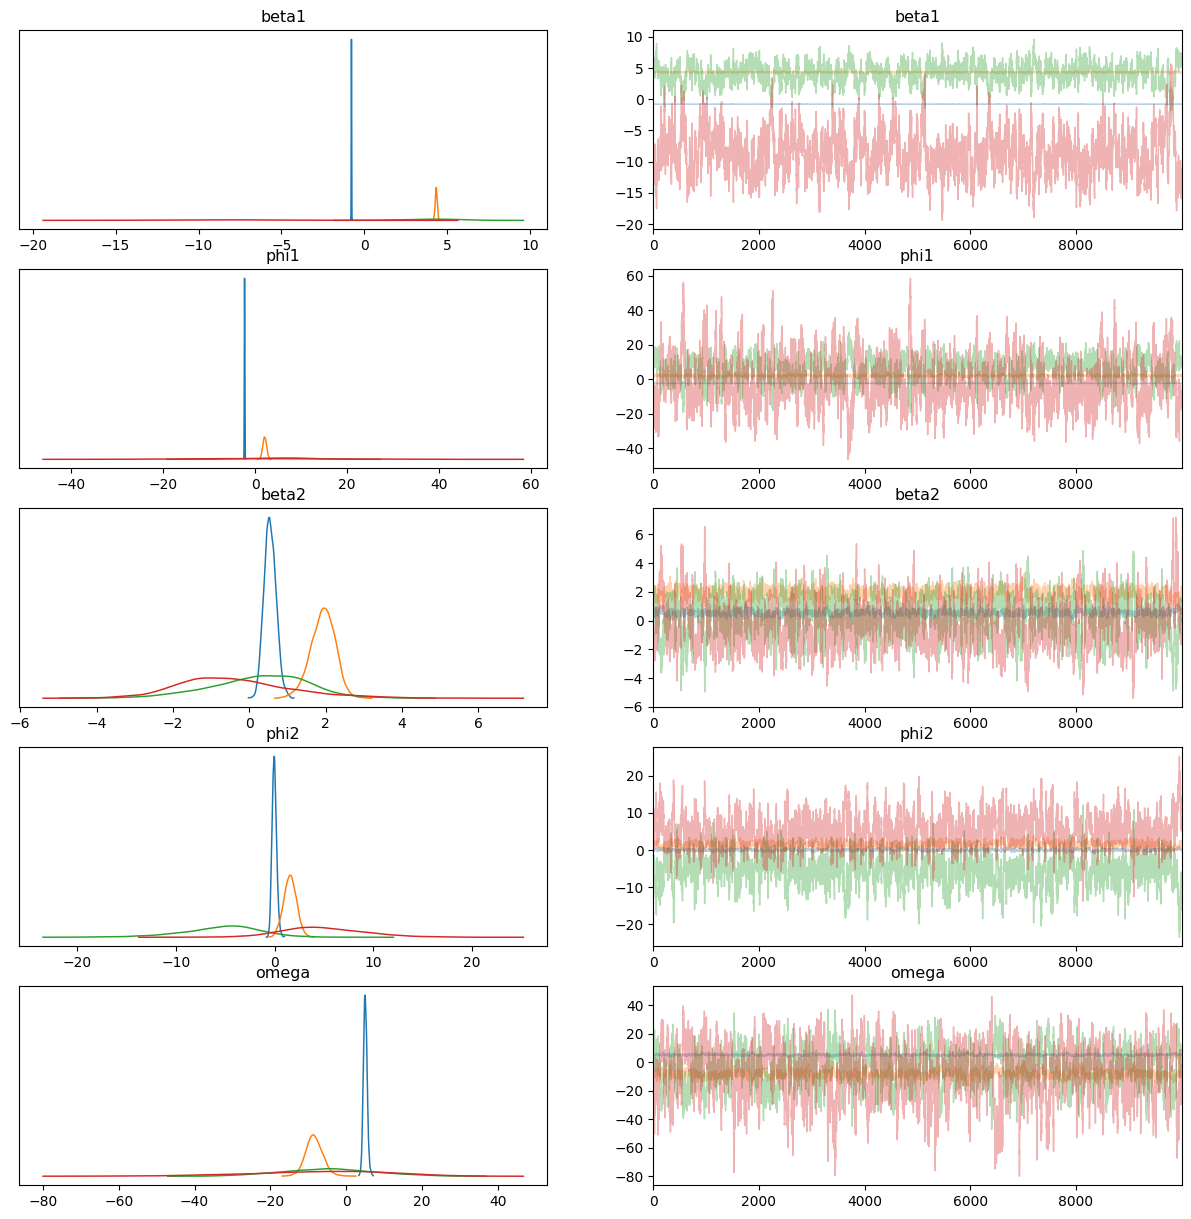

In [44]:
trace_az = {k: jnp.expand_dims(v,axis=0) for k, v in trace_m3.items()}
numpyro_data = az.from_dict(
    trace_az
)

az.plot_trace(
    numpyro_data.posterior, 
    var_names=['beta1','phi1','beta2','phi2','omega'],
    figsize=(15,15)
)
None

In [45]:
posterior_predictive_m3 = Predictive(
    mixture_model_m2, posterior_samples=trace_m3, 
    #batch_ndims = 2,
    return_sites=[
        'obs','gate'
    ])(rng_key_, x_test)

# collect predictive variables
ci = 0.95

hpdi_sim_mix_m3 = hpdi(posterior_predictive_m3['obs'], ci)
mean_pred_mix_m3 = jnp.mean(posterior_predictive_m3['obs'],axis=0)

gate = posterior_predictive_m3['gate']

gate_mean = np.mean(gate,axis=0)

switch1 = np.where(gate_mean[:,1]<0.5,np.nan, 0)
switch2 = np.where(gate_mean[:,1]>=0.5,np.nan, 0)

# Save the prediction results

In [23]:
preds_dict = {'preds_m2':mean_pred_mix_m3[0,:],'preds_m0': mean_pred_single_m0, 'preds_m1':mean_pred_single_m1[0,:], 
              'hpdi_m0':hpdi_sim_single_m0, 'hpdi_m1':hpdi_sim_single_m1, 'hpdi_m2':hpdi_sim_mix_m3,
              'obs':hd_test, 'mix_weights_m2':gate_mean[:,1]}


In [24]:
import pickle

with open('./../results/glenreagh/glenreagh_preds', 'wb') as fp:
    pickle.dump(preds_dict, fp)
    print('preds saved successfully to file')

preds saved successfully to file


# Save traces

In [25]:
with open('./../results/glenreagh/glenreagh_m0', 'wb') as fp:
    pickle.dump(trace_m0, fp)
    print('trace m_0 saved successfully to file')

with open('./../results/glenreagh/glenreagh_m1', 'wb') as fp:
    pickle.dump(trace_m1, fp)
    print('trace m_1 saved successfully to file')

with open('./../results/glenreagh/glenreagh_m2', 'wb') as fp:
    pickle.dump(trace_m3, fp)
    print('trace m_2 saved successfully to file')

trace m_0 saved successfully to file
trace m_1 saved successfully to file
trace m_2 saved successfully to file


# Plot of out of sample prediction

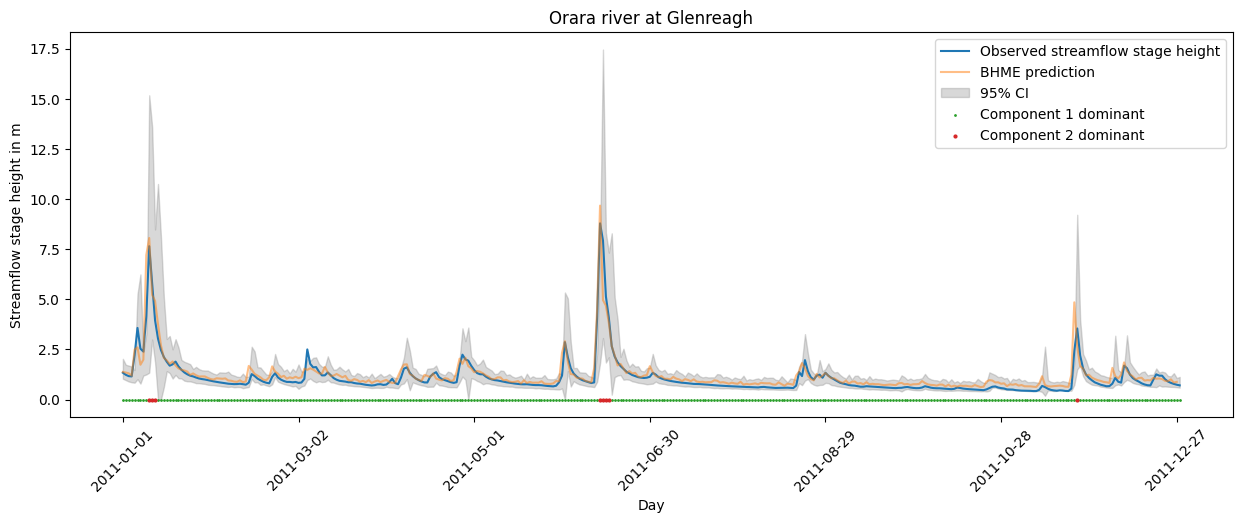

In [46]:

plt.figure(figsize=(15,5))
plt.plot(hd_test, label = 'Observed streamflow stage height')
plt.plot(mean_pred_mix_m3[0,1:], label = 'BHME prediction', alpha=0.5)
plt.fill_between([x for x in range(len(hd_test))],hpdi_sim_mix_m3[0,0,:], hpdi_sim_mix_m3[1,0,:], label='95% CI', color='#808080', alpha=0.3)

plt.xticks(ticks=[x for x in range(0,len(hd_test),60)],labels=[ticklabels_test[x] for x in range(0,len(hd_test),60)],rotation=45)
plt.scatter([x for x in range(len(hd_test))],switch2, label = 'Component 1 dominant', s=1, c='#2ca02c')
plt.scatter([x for x in range(len(hd_test))],switch1, label = 'Component 2 dominant', s=4, c='#d62728')
plt.title('Orara river at Glenreagh')
plt.ylabel('Streamflow stage height in m')
plt.xlabel('Day')
plt.legend()
plt.show()

# Performance metrics

In [52]:
from sklearn.metrics import mean_squared_error

def nse(predictions, targets):
    return (1-(jnp.sum((targets-predictions)**2)/jnp.sum((targets-jnp.mean(targets))**2)))

In [53]:
print('Base model (M0) r2: ',jnp.corrcoef(mean_pred_single_m0,hd_test)[0,1])
print('Single model (M1) r2: ',jnp.corrcoef(mean_pred_single_m1[0,:],hd_test)[0,1])
print('Mixture model (M2) r2: ',jnp.corrcoef(mean_pred_mix_m3[0,:],hd_test)[0,1])

Base model (M0) r2:  0.8355462
Single model (M1) r2:  0.89829665
Mixture model (M2) r2:  0.90218455


In [54]:
print('Base model (M0) MSE: ',mean_squared_error(mean_pred_single_m0,hd_test))
print('Single model (M1) MSE: ',mean_squared_error(mean_pred_single_m1[0,:],hd_test))
print('Mixture model (M2) MSE: ',mean_squared_error(mean_pred_mix_m3[0,:],hd_test))

Base model (M0) MSE:  3.416844
Single model (M1) MSE:  0.22709405
Mixture model (M2) MSE:  0.18352388


In [55]:
print('Base model (M0) NSE: ',nse(mean_pred_single_m0,hd_test))
print('Single model (M1) NSE: ',nse(mean_pred_single_m1[0,:],hd_test))
print('Mixture model (M2) NSE: ',nse(mean_pred_mix_m3[0,:],hd_test[:]))

Base model (M0) NSE:  -2.9807246
Single model (M1) NSE:  0.7354287
Mixture model (M2) NSE:  0.78618926


In [51]:
# for m0, it is troublesome to get waic 

dictionary = az.from_numpyro(mcmc_m0).to_dict()

# delete manually the reject betas
del dictionary['log_likelihood']['reject_beta']
del dictionary['observed_data']['reject_beta']

az_inference = az.from_dict(posterior=dictionary['posterior'], log_likelihood=dictionary['log_likelihood'], observed_data=dictionary['observed_data'])

#compare and rank the models
az.compare(
    {"single": az.from_numpyro(mcmc_m1), "mixture": az.from_numpyro(mcmc_m3), 'base': az_inference},
    ic="waic",
    scale="deviance",
)

/usr/local/lib/python3.8/dist-packages/arviz/stats/stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/arviz/stats/stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/arviz/stats/stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
mixture,0,-791.032693,21.269478,0.000000,0.999542,76.321075,0.000000,True,deviance
single,1,-57.958516,37.790932,733.074177,0.000000,209.158314,166.496913,True,deviance
base,2,3677.469453,174.198883,4468.502146,0.000458,363.574740,357.823457,True,deviance
